In [1]:
from utils.visualization import show_result
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

import config_mv
from models.patchcore import PatchCore
from models.backbone import get_backbone
from datasets.mvtec import MyData
from utils.metrics import get_image_auc
from utils.visualization import show_result, denormalize


In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

mps


In [3]:
train_data = MyData(
    config_mv.CLASS_NAME,
    phase="train",
    batch_size = config_mv.BATCH_SIZE,
    shuffle=False,
    limit = config_mv.TRAIN_LIMIT,
)

test_data = MyData(
    config_mv.CLASS_NAME,
    phase="test",
    batch_size = config_mv.BATCH_SIZE,
    shuffle=False,
    limit  = config_mv.TEST_LIMIT,
    limit_per_class =config_mv.TEST_LIMIT_PER_CLASS,
)

In [4]:
backbone = get_backbone()
patchcore = PatchCore(backbone, k=config_mv.K, device=device)

patchcore.fit(train_data)

In [5]:
scores = []
heatmaps = []
imgs = []
for img, label in test_data:
    score, heatmap = patchcore.predict(img)
    scores.append(score.item())
    heatmaps.append(heatmap)
    imgs.append(img)

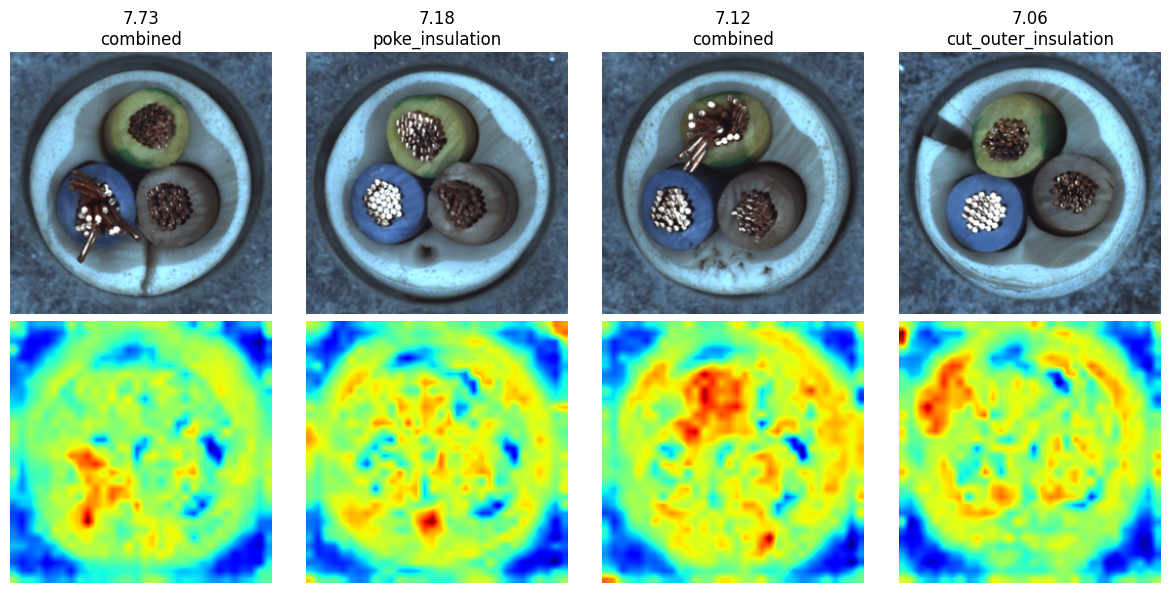

In [6]:
show_result(test_data, scores, heatmaps, k=4)